## Sigmoid Sparsity Parameter Tuning

In [1]:
import numpy as np
import matplotlib
# matplotlib.use('TkAgg')  # Needed for interactive plots in Jupyter Lab
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from attack.run_gridsearch import load_datapoints, PathManager

def sigmoid(x):
    """Standard sigmoid function."""
    return 1 / (1 + np.exp(-x))

def plot_sigmoid_transitions():
    """
    Create interactive visualization of sigmoid transitions for L0 norm approximation.
    Allows experimenting with different beta and gamma values.
    """
    # Create figure and axis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    plt.subplots_adjust(bottom=0.25)
    
    # Create x values (feature differences)
    x = np.linspace(0, 1, 1000)
    
    # Initial parameter values
    beta_init = 10.0
    gamma_init = 0.1
    
    # Precompute some standard parameter combinations for comparison
    param_combinations = [
        (5.0, 0.1, 'Beta=5, Gamma=0.1'),
        (10.0, 0.1, 'Beta=10, Gamma=0.1'),
        (20.0, 0.1, 'Beta=20, Gamma=0.1'),
        (10.0, 0.2, 'Beta=10, Gamma=0.2'),
        (50.0, 0.1, 'Beta=50, Gamma=0.1')
    ]
    
    # Plot multiple parameter combinations
    for beta, gamma, label in param_combinations:
        y = sigmoid(beta * x - gamma)
        ax1.plot(x, y, label=label)
    
    # Current parameter line (will be updated)
    main_line, = ax2.plot(x, sigmoid(beta_init * x - gamma_init), 'r-', linewidth=3, label=f'Beta={beta_init}, Gamma={gamma_init}')
    
    # Set plot properties
    ax1.set_xlabel('Feature Difference (|x_adv - x_orig|)')
    ax1.set_ylabel('Contribution to Sparsity Count')
    ax1.set_title('Comparison of Different Parameter Combinations')
    ax1.grid(True)
    ax1.legend()
    
    ax2.set_xlabel('Feature Difference (|x_adv - x_orig|)')
    ax2.set_ylabel('Contribution to Sparsity Count')
    ax2.set_title('Interactive Parameter Tuning')
    ax2.grid(True)
    
    # Add horizontal line at 0.5 (halfway point in transition)
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
    threshold_line = ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
    
    # Add text annotation for threshold
    threshold_text = ax2.text(0.5, 0.52, f'Threshold ≈ {gamma_init/beta_init:.3f}', 
                             ha='center', va='bottom')
    
    # Add area for sliders
    ax_beta = plt.axes([0.25, 0.15, 0.65, 0.03])
    ax_gamma = plt.axes([0.25, 0.1, 0.65, 0.03])
    
    # Create sliders
    beta_slider = Slider(ax_beta, 'Beta', 1.0, 100.0, valinit=beta_init)
    gamma_slider = Slider(ax_gamma, 'Gamma', 0.01, 0.5, valinit=gamma_init)
    
    # Update function
    def update(val):
        beta = beta_slider.val
        gamma = gamma_slider.val
        main_line.set_ydata(sigmoid(beta * x - gamma))
        
        # Update threshold approximation (where sigmoid = 0.5)
        threshold_approx = gamma / beta
        threshold_text.set_text(f'Threshold ≈ {threshold_approx:.3f}')
        
        # Update line title
        ax2.set_title(f'Interactive Parameter Tuning (Beta={beta:.1f}, Gamma={gamma:.3f})')
        
        fig.canvas.draw_idle()
    
    # Register update function with sliders
    beta_slider.on_changed(update)
    gamma_slider.on_changed(update)
    
    # Add reset button
    reset_ax = plt.axes([0.8, 0.025, 0.1, 0.04])
    reset_button = Button(reset_ax, 'Reset')
    
    def reset(event):
        beta_slider.reset()
        gamma_slider.reset()
    
    reset_button.on_clicked(reset)
    
    plt.show()

def try_different_parameters(feature_diff_values):
    """
    Evaluate different beta/gamma combinations on actual feature differences.
    
    Args:
        feature_diff_values: Array of actual feature difference values from The dataset
    """
    # Parameter combinations to try
    beta_values = [5, 10, 20, 50]
    gamma_values = [0.05, 0.1, 0.2, 0.3]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create histogram of feature differences
    counts, bins, _ = ax.hist(feature_diff_values, bins=50, alpha=0.5, 
                             color='gray', label='Feature Differences')
    
    # Overlay sigmoid curves
    x = np.linspace(0, max(feature_diff_values), 1000)
    
    for beta in beta_values:
        for gamma in gamma_values:
            y = sigmoid(beta * x - gamma)
            ax.plot(x, y * max(counts) * 0.8, label=f'β={beta}, γ={gamma}')
    
    ax.set_xlabel('Feature Difference (|x_adv - x_orig|)')
    ax.set_ylabel('Count / Normalized Sigmoid')
    ax.set_title('Feature Differences with Sigmoid Curves')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

def load_adversarial_examples(dataset, model, attack_type, params, folder="adversarial_examples"):
    """
    Load original and adversarial examples for analysis.
    """
    try:
        # Use the load_datapoints function from the provided code
        original_instances, original_latent_vectors, latent_vectors, adversarial_examples, attack_success, confidences = load_datapoints(
            params, dataset, model, attack_type, folder
        )
        
        # Calculate absolute differences in feature space
        feature_differences = np.abs(adversarial_examples - original_instances)
        
        # Create boolean mask for successful attacks
        success_mask = attack_success.astype(bool)
        
        print(f"Loaded {len(original_instances)} examples")
        print(f"Successful attacks: {sum(success_mask)}/{len(success_mask)} ({sum(success_mask)/len(success_mask)*100:.2f}%)")
        
        return original_instances, adversarial_examples, feature_differences, success_mask
        
    except Exception as e:
        print(f"Error loading adversarial examples: {str(e)}")
        return None, None, None, None

def analyze_feature_differences(feature_differences, success_mask=None):
    """
    Extremely simplified analysis that avoids all numpy conversion issues
    """
    # If success_mask provided, filter to only look at successful attacks
    if success_mask is not None:
        if np.sum(success_mask) > 0:
            feature_differences = feature_differences[success_mask]
            print(f"Analyzing {len(feature_differences)} successful adversarial examples")
        else:
            print("No successful attacks to analyze")
            return None
    
    # Simply count total changes and get overall sparsity
    change_threshold = 1e-5  # Small threshold to account for numerical precision
    total_changes = np.sum(feature_differences > change_threshold)
    total_elements = feature_differences.size
    
    print(f"\nTotal feature changes: {total_changes}")
    print(f"Total elements: {total_elements}")
    print(f"Overall sparsity: {total_changes/total_elements*100:.2f}%")
    
    # Average changes per example
    changes_per_example = np.sum(feature_differences > change_threshold, axis=1)
    avg_changes = np.mean(changes_per_example)
    num_features = feature_differences.shape[1]
    
    print(f"Average changes per example: {avg_changes:.2f} out of {num_features}")
    print(f"Average example sparsity: {avg_changes/num_features*100:.2f}%")
    
    # Skip the feature-by-feature analysis to avoid conversion issues
    
    # Return flattened differences for visualization
    return feature_differences.flatten()

def visualize_differences_and_sigmoid(feature_differences):
    """
    Visualize the feature differences and test different sigmoid parameters.
    """
    # Filter out extremely small values that might be due to numerical precision
    feature_differences = feature_differences[feature_differences > 1e-10]
    
    # Create histogram of differences
    plt.figure(figsize=(12, 6))
    plt.hist(feature_differences, bins=50, alpha=0.7)
    plt.title("Distribution of Feature Differences")
    plt.xlabel("Absolute Difference |x_adv - x_orig|")
    plt.ylabel("Count")
    plt.yscale('log')  # Log scale often helps visualize the distribution better
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Use the provided visualization functions to test different sigmoid parameters
    print("\nTesting different sigmoid parameter combinations:")
    try_different_parameters(feature_differences)
    
    # Also show the interactive plot
    print("\nLaunching interactive sigmoid visualization:")
    plot_sigmoid_transitions()


### Adult Dataset

Loaded 500 examples
Successful attacks: 255/500 (51.00%)
Analyzing 255 successful adversarial examples

Total feature changes: 1022599
Total elements: 1530000
Overall sparsity: 66.84%
Average changes per example: 334.18 out of 500
Average example sparsity: 66.84%


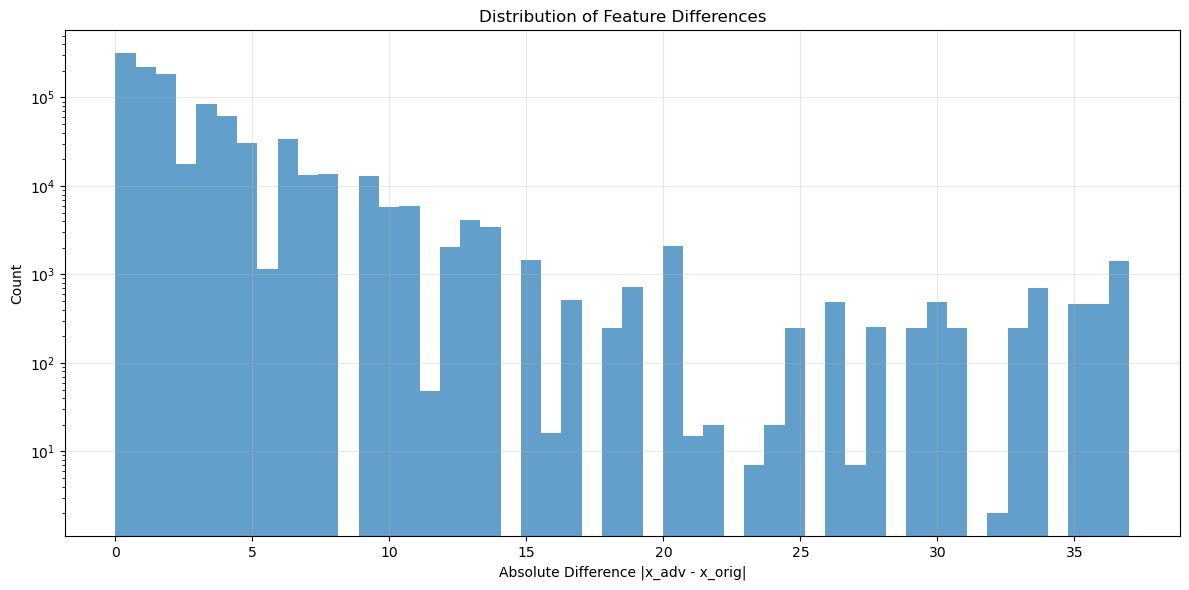


Testing different sigmoid parameter combinations:


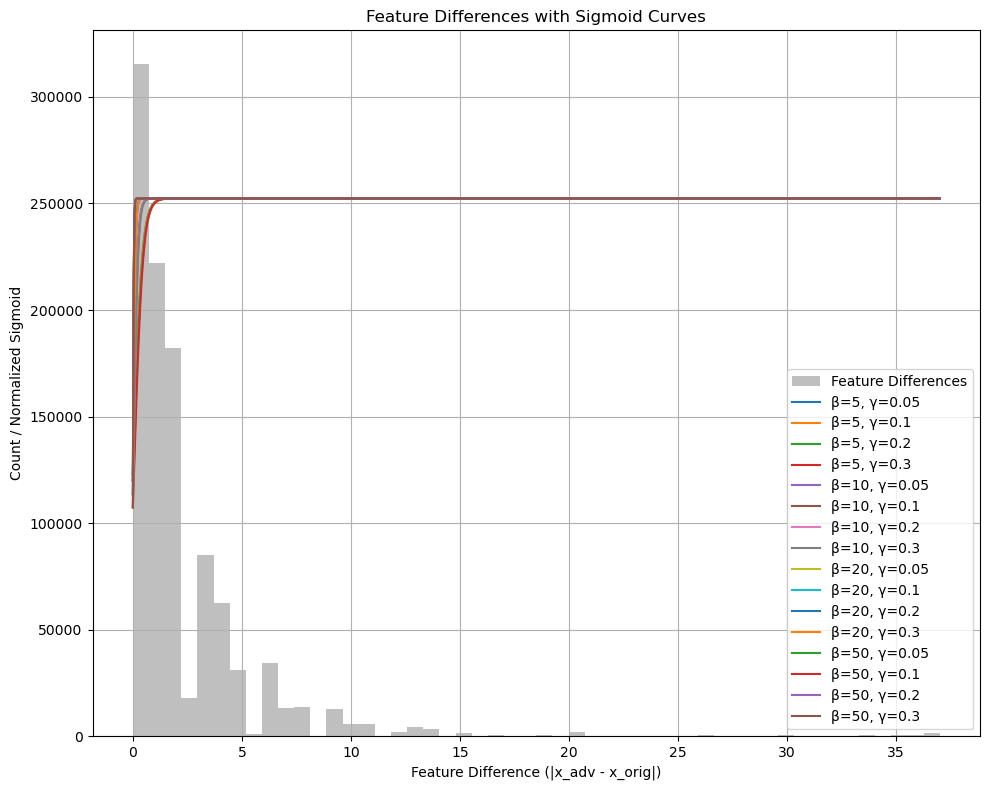


Launching interactive sigmoid visualization:


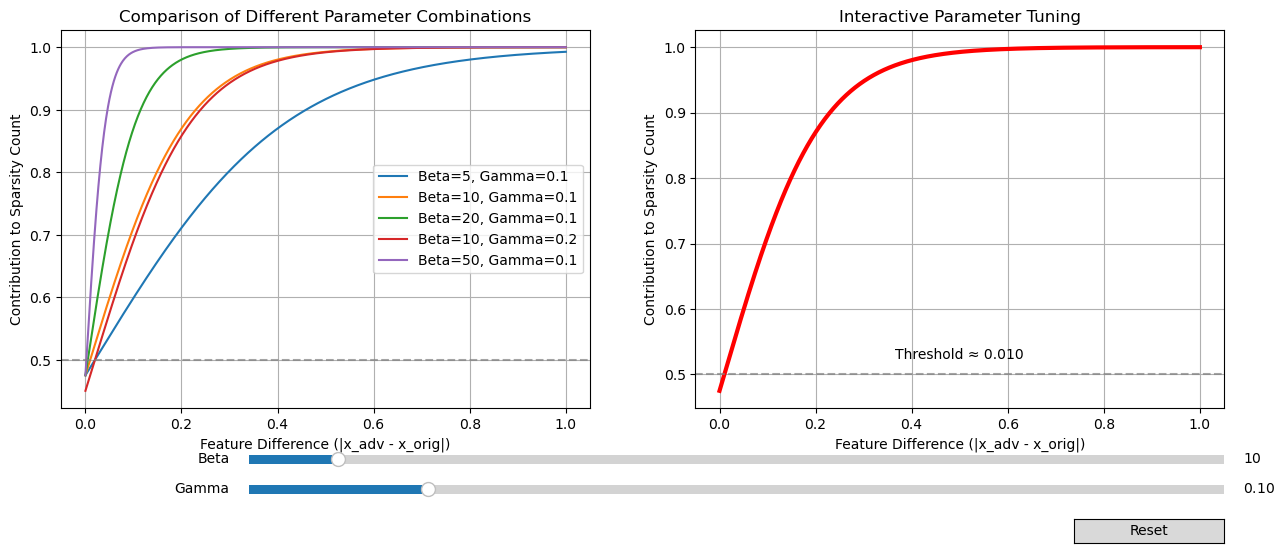

In [2]:
# Parameters for loading adversarial examples
dataset = "adult"
model = "MLP"
attack_type = "baseline"

# Attack parameters
params = {
    'sample_num': 500,
    '_lambda': 1,
    'lr': 1e-1,
    'max_iter': 300,
    'optimizer': 'adam',
    'kappa': 0.0,
}

# Load the data
original_instances, adversarial_examples, feature_differences, success_mask = load_adversarial_examples(
    dataset, model, attack_type, params
)

if original_instances is not None:
    # Analyze the differences with truly error-free implementation
    flattened_diffs = analyze_feature_differences(
        feature_differences, 
        success_mask
    )
    
    # Visualize and test sigmoid parameters
    if flattened_diffs is not None:
        visualize_differences_and_sigmoid(flattened_diffs)


## Analysis of The Adversarial Examples

- The histogram (Image 1) shows that feature differences span a wide range (0-35), with most concentrated between 0-10
- There's a large spike very close to 0, followed by clusters around 2-5 and 7-10
- The sigmoid curve visualization (Image 2) shows all parameter combinations create very steep transitions that occur early (< 1.0)
- The current successful adversarial examples have relatively high sparsity (66.84%)

## Interpretation

The adversarial attack is already modifying a significant portion of features (334 out of 500 features on average). Adding a sparsity term should encourage fewer feature modifications.

Based on the distribution of feature differences:

1. **Small differences (near zero)**: These may be numerical noise rather than meaningful changes
2. **Medium differences (1-5)**: These appear to be common and likely represent actual feature modifications
3. **Larger differences (>5)**: These represent significant feature changes that are less common

## Recommended Parameters

Given the goal of adding sparsity to encourage fewer modified features:

- **Beta = 20**: This provides a sufficiently steep transition to clearly distinguish between modified and unmodified features
- **Gamma = 0.2 to 0.3**: This will place the threshold around 0.01-0.015, which appears appropriate based on the data

This combination will:
- Ignore very small modifications that may be numerical noise (<0.01)
- Count substantial modifications (>0.03) fully
- Create a clear decision boundary between what counts as "changed" versus "unchanged" features

The higher gamma value (0.2-0.3) will be more aggressive in enforcing sparsity, which seems appropriate given the current high modification rate of 66.84%.

## Implementation Suggestion

When implementing this in the VAESparsityAttack class, I recommend:
- Start with `lambda_sparsity` at a moderate value (around 0.5-1.0)
- If the attack success rate drops too much, decrease `lambda_sparsity`
- If you want even sparser solutions, increase `lambda_sparsity`

These parameters should help you achieve a better balance between successful adversarial examples and feature-sparse perturbations.

## Comparison of Sparsity Attack and Non-Sparsity Attack

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from attack.run_gridsearch import PathManager, load_datapoints


def load_attack_data(dataset, model, attack_type, params, base_folder="adversarial_examples"):
    """
    Load adversarial attack results from files using PathManager.
    
    Args:
        dataset: Name of the dataset
        model: Name of the model
        attack_type: Type of attack ('baseline', 'sparsity', etc.)
        params: Dictionary of attack parameters
        base_folder: Root folder for adversarial examples
    
    Returns:
        Dictionary containing attack data or None if loading fails
    """
    try:
        # Use PathManager to get the attack folder path
        base_path = PathManager.get_base_folder(base_folder, dataset, model, attack_type)
        attack_folder = PathManager.get_attack_folder(base_path, attack_type, params)
        
        # Check if folder exists
        if not os.path.exists(attack_folder):
            print(f"Attack folder not found: {attack_folder}")
            return None
        
        # Use existing load_datapoints function to get the data
        original_instances, original_latent, latent_vectors, adversarial_examples, success_flags, confidences = load_datapoints(
            params, dataset, model, attack_type, base_folder
        )
        
        # Organize data into a dictionary for consistent interface
        data = {
            'original_instances': original_instances,
            'original_latent': original_latent,
            'adversarial_examples': adversarial_examples,
            'latent_vectors': latent_vectors,
            'success_flags': success_flags,
            'confidences': confidences
        }
        
        # Check if we have loaded any data
        if len(data['original_instances']) == 0:
            print(f"No data found in folder: {attack_folder}")
            return None
            
        print(f"Successfully loaded {len(data['original_instances'])} samples for {attack_type}")
        return data
        
    except Exception as e:
        print(f"Error loading data for {attack_type}: {str(e)}")
        return None


def compute_sparsity_metrics(attack_data, threshold=1e-5):
    """
    Compute sparsity metrics from attack data.
    
    Args:
        attack_data: Dictionary containing attack data
        threshold: Threshold for considering a feature as changed
        
    Returns:
        Dictionary of sparsity metrics or None if computation fails
    """
    try:
        # Extract data
        original = attack_data['original_instances']
        adversarial = attack_data['adversarial_examples']
        success_flags = attack_data['success_flags']
        
        print(f"Original shape: {original.shape}")
        print(f"Adversarial shape: {adversarial.shape}")
        
        # Check for dimension mismatch and reshape if needed
        if original.shape != adversarial.shape:
            print(f"Shape mismatch between original and adversarial examples.")
            # If adversarial examples have an extra dimension, reshape them
            if len(adversarial.shape) > len(original.shape):
                if adversarial.shape[0] == original.shape[0]:
                    print(f"Reshaping adversarial examples from {adversarial.shape} to match original shape {original.shape}")
                    adversarial = adversarial.reshape(original.shape)
            # If original has extra dimension, reshape it
            elif len(original.shape) > len(adversarial.shape):
                if original.shape[0] == adversarial.shape[0]:
                    print(f"Reshaping original examples from {original.shape} to match adversarial shape {adversarial.shape}")
                    original = original.reshape(adversarial.shape)
        
        # Filter for successful attacks
        success_mask = success_flags.astype(bool)
        success_count = np.sum(success_mask)
        
        if success_count == 0:
            print("No successful attacks found")
            return None
        
        # Get successful examples
        original_successful = original[success_mask]
        adversarial_successful = adversarial[success_mask]
        
        print(f"After filtering, original shape: {original_successful.shape}")
        print(f"After filtering, adversarial shape: {adversarial_successful.shape}")
        
        # Calculate absolute differences
        diffs = np.abs(adversarial_successful - original_successful)
        print(f"Differences shape: {diffs.shape}")
        
        # Calculate total features per sample
        if len(diffs.shape) == 1:
            # Single sample case
            total_features_per_sample = diffs.size
            diffs = diffs.reshape(1, -1)
        elif len(diffs.shape) == 2:
            # Normal case: (n_samples, n_features)
            total_features_per_sample = diffs.shape[1]
        else:
            # Multi-dimensional case
            total_features_per_sample = np.prod(diffs.shape[1:])
            diffs = diffs.reshape(diffs.shape[0], -1)
            
        print(f"Total features per sample: {total_features_per_sample}")
        print(f"Working with differences shape: {diffs.shape}")
        
        # Apply threshold to determine changed features
        changed_features = (diffs > threshold)
        
        # Count changes per sample
        feature_counts = np.sum(changed_features, axis=1)
        print(f"Feature counts shape: {feature_counts.shape}")
        print(f"Feature counts min: {np.min(feature_counts)}, max: {np.max(feature_counts)}, mean: {np.mean(feature_counts)}")
        
        # Feature-wise change frequency
        feature_change_freq = np.mean(changed_features, axis=0)
        
        # Calculate norms
        l0_norm = np.mean(feature_counts)
        l1_norm = np.mean(np.sum(diffs, axis=1))
        l2_norm = np.mean(np.sqrt(np.sum(np.square(diffs), axis=1)))
        
        # Overall sparsity (percentage of all elements changed)
        total_elements = diffs.size
        changed_elements = np.sum(changed_features)
        overall_sparsity = changed_elements / total_elements
        
        # Compute metrics for original vs latent space
        original_latent = attack_data['original_latent'][success_mask]
        adversarial_latent = attack_data['latent_vectors'][success_mask]
        
        # Ensure latent vectors are properly shaped
        if original_latent.shape != adversarial_latent.shape:
            print(f"Shape mismatch in latent space: original {original_latent.shape}, adversarial {adversarial_latent.shape}")
            
        latent_diffs = np.abs(adversarial_latent - original_latent)
        
        # Reshape latent differences if needed
        if len(latent_diffs.shape) > 2:
            latent_diffs = latent_diffs.reshape(latent_diffs.shape[0], -1)
            
        latent_changed = (latent_diffs > threshold)
        latent_l0 = np.mean(np.sum(latent_changed, axis=1))
        
        return {
            'success_rate': success_count / len(success_flags),
            'overall_sparsity': overall_sparsity,
            'avg_features_changed': l0_norm,
            'median_features_changed': np.median(feature_counts),
            'max_features_changed': np.max(feature_counts),
            'min_features_changed': np.min(feature_counts),
            'feature_counts': feature_counts,
            'feature_change_freq': feature_change_freq,
            'l0_norm': l0_norm,
            'l1_norm': l1_norm,
            'l2_norm': l2_norm,
            'latent_l0_norm': latent_l0,
            'num_features': total_features_per_sample,
            'num_successful': success_count,
            'total_samples': len(success_flags)
        }
        
    except Exception as e:
        print(f"Error computing metrics: {str(e)}")
        import traceback
        traceback.print_exc()
        return None


def print_metrics_table(metrics_list):
    """
    Print a comparison table of metrics for different attacks.
    
    Args:
        metrics_list: List of dictionaries containing metrics for each attack
    """
    if not metrics_list:
        print("No metrics to display")
        return
    
    # Print header
    print("\n" + "="*100)
    print(f"{'Attack Type':<15} {'Success %':<10} {'Avg Changed':<12} {'Sparsity %':<12} "
          f"{'L0 Norm':<10} {'L1 Norm':<10} {'L2 Norm':<10} {'Latent L0':<10}")
    print("-"*100)
    
    # Print metrics for each attack
    for metrics in metrics_list:
        attack_type = metrics['attack_setting']
        success_rate = metrics['metrics']['success_rate'] * 100
        avg_features = metrics['metrics']['avg_features_changed']
        sparsity = metrics['metrics']['overall_sparsity'] * 100
        l0_norm = metrics['metrics']['l0_norm']
        l1_norm = metrics['metrics']['l1_norm']
        l2_norm = metrics['metrics']['l2_norm']
        latent_l0 = metrics['metrics']['latent_l0_norm']
        
        print(f"{attack_type:<15} {success_rate:8.2f}% {avg_features:10.2f} {sparsity:10.2f}% "
              f"{l0_norm:10.2f} {l1_norm:10.2f} {l2_norm:10.2f} {latent_l0:10.2f}")
    
    print("="*100)


def plot_feature_counts_histogram(metrics_list):
    """
    Create histograms of feature change counts for each attack.
    
    Args:
        metrics_list: List of dictionaries containing metrics for each attack
    """
    if not metrics_list:
        return
        
    # Create a figure with subplots for each attack
    n_attacks = len(metrics_list)
    fig, axes = plt.subplots(n_attacks, 1, figsize=(10, 5 * n_attacks), sharex=True)
    
    # Handle single subplot case
    if n_attacks == 1:
        axes = [axes]
    
    # Plot histograms
    for i, metrics in enumerate(metrics_list):
        attack_type = metrics['attack_setting']
        feature_counts = metrics['metrics']['feature_counts']
        
        # Ensure feature_counts is a 1D array
        if hasattr(feature_counts, 'shape') and len(feature_counts.shape) > 1:
            print(f"Warning: feature_counts for {attack_type} has shape {feature_counts.shape}, flattening...")
            
        avg_features = metrics['metrics']['avg_features_changed']
        median_features = metrics['metrics']['median_features_changed']
        total_features = metrics['metrics']['num_features']
        
        # Create histogram
        ax = axes[i]
        # Convert feature_counts to 1D array if needed
        if hasattr(feature_counts, 'shape') and len(feature_counts.shape) > 1:
            feature_counts_1d = feature_counts.flatten()
        else:
            feature_counts_1d = feature_counts
            
        # Calculate number of bins safely
        if len(feature_counts_1d) > 0:
            max_val = np.max(feature_counts_1d)
            num_bins = min(30, int(max_val)+1)
        else:
            num_bins = 10  # Default if empty
            
        ax.hist(feature_counts_1d, bins=num_bins, 
                alpha=0.7, color='steelblue', edgecolor='black')
        
        # Add vertical lines for mean and median
        ax.axvline(avg_features, color='red', linestyle='dashed', linewidth=2, 
                   label=f'Mean: {avg_features:.2f}')
        ax.axvline(median_features, color='green', linestyle='dashed', linewidth=2, 
                   label=f'Median: {median_features:.2f}')
        
        # Add labels and grid
        ax.set_title(f"{attack_type} - Distribution of Changed Features")
        ax.set_ylabel('Number of Samples')
        ax.set_xlabel('Number of Changed Features')
        ax.grid(alpha=0.3)
        ax.legend()
        
        # Set x-axis to integer ticks
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        # Add percentage of total features as a secondary x-axis
        secax = ax.secondary_xaxis('top', functions=(
            lambda x: x/total_features*100,  # Forward transform
            lambda x: x*total_features/100)  # Inverse transform
        )
        secax.set_xlabel('Percent of Features Changed')
    
    plt.tight_layout()
    plt.show()


def plot_feature_change_comparison(metrics_list):
    """
    Create a side-by-side comparison of feature change distributions.
    
    Args:
        metrics_list: List of dictionaries containing metrics for each attack
    """
    if not metrics_list:
        return
    
    plt.figure(figsize=(10, 6))
    
    # Prepare data for box plots
    data = []
    labels = []
    
    for metrics in metrics_list:
        feature_counts = metrics['metrics']['feature_counts']
        # Ensure feature_counts is a 1D array
        if hasattr(feature_counts, 'shape') and len(feature_counts.shape) > 1:
            feature_counts = feature_counts.flatten()
        data.append(feature_counts)
        labels.append(metrics['attack_setting'])
    
    # Create box plot
    box_parts = plt.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
    for i, box in enumerate(box_parts['boxes']):
        box.set(facecolor=colors[i % len(colors)])
    
    plt.title('Comparison of Feature Changes Across Attack Methods')
    plt.ylabel('Number of Changed Features')
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add total features as text
    if metrics_list:
        total_features = metrics_list[0]['metrics']['num_features']
        plt.text(0.02, 0.95, f"Total Features: {total_features}", transform=plt.gca().transAxes,
                 bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


def plot_top_changed_features(metrics_list, feature_names=None, top_n=20):
    """
    Create a heatmap of the most frequently changed features.
    
    Args:
        metrics_list: List of dictionaries containing metrics for each attack
        feature_names: Optional list of feature names
        top_n: Number of top features to display
    """
    if not metrics_list:
        return
    
    # Stack feature change frequencies from all attacks
    all_freqs = np.vstack([metrics['metrics']['feature_change_freq'] for metrics in metrics_list])
    attack_types = [metrics['attack_setting'] for metrics in metrics_list]
    
    # Get indices of top N most changed features (on average across attacks)
    avg_freqs = np.mean(all_freqs, axis=0)
    top_indices = np.argsort(-avg_freqs)[:min(top_n, len(avg_freqs))]
    
    # Create feature labels
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in top_indices]
    else:
        try:
            feature_names = [feature_names[i] for i in top_indices]
        except (IndexError, TypeError):
            feature_names = [f"Feature {i}" for i in top_indices]
    
    # Create heatmap data
    heatmap_data = all_freqs[:, top_indices]
    
    # Create heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", 
                xticklabels=feature_names, yticklabels=attack_types)
    
    plt.title('Most Frequently Changed Features by Attack Method')
    plt.xlabel('Features')
    plt.ylabel('Attack Method')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison(metrics_list):
    """
    Create a bar chart comparing key metrics between attack methods.
    
    Args:
        metrics_list: List of dictionaries containing metrics for each attack
    """
    if not metrics_list:
        return
    
    attack_types = [metrics['attack_setting'] for metrics in metrics_list]
    success_rates = [metrics['metrics']['success_rate'] * 100 for metrics in metrics_list]
    sparsity_rates = [metrics['metrics']['overall_sparsity'] * 100 for metrics in metrics_list]
    
    # Normalize feature counts to percentages for easier comparison
    num_features = metrics_list[0]['metrics']['num_features']
    feature_percentages = [metrics['metrics']['avg_features_changed'] / num_features * 100 
                         for metrics in metrics_list]
    
    # Create grouped bar chart
    x = np.arange(len(attack_types))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width, success_rates, width, label='Attack Success Rate (%)', color='skyblue')
    bars2 = ax.bar(x, sparsity_rates, width, label='Overall Sparsity (%)', color='lightgreen')
    bars3 = ax.bar(x + width, feature_percentages, width, label='Avg. Features Changed (%)', color='salmon')
    
    # Add labels, title and legend
    ax.set_xlabel('Attack Type')
    ax.set_ylabel('Percentage')
    ax.set_title('Comparison of Attack Methods')
    ax.set_xticks(x)
    ax.set_xticklabels(attack_types)
    ax.legend()
    
    # Add exact values on top of bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)
    
    plt.tight_layout()
    plt.show()


def compare_attack_sparsity(dataset, model, attack_configs, feature_names=None, threshold=1e-5):
    """
    Compare sparsity metrics between different adversarial attack methods.
    
    Args:
        dataset: Name of the dataset
        model: Name of the model
        attack_configs: List of dictionaries with attack_type and params for each attack
        feature_names: Optional list of feature names
    
    Returns:
        List of dictionaries containing metrics for each attack
    """
    print(f"\nComparing attacks for {dataset} dataset and {model} model:")
    
    metrics_list = []
    
    for config in attack_configs:
        attack_type = config['attack_type']
        params = config['params']
        attack_setting = config['attack_setting']
        
        print(f"\nProcessing {attack_type} attack...")
        
        # Load attack results
        attack_data = load_attack_data(dataset, model, attack_type, params)
        
        if attack_data is None:
            print(f"Skipping {attack_type} due to data loading failure")
            continue
        
        # Compute sparsity metrics
        metrics = compute_sparsity_metrics(attack_data, threshold=threshold)
        
        if metrics is None:
            print(f"Skipping {attack_type} due to metrics computation failure")
            continue
        
        # Add to metrics list
        metrics_list.append({
            'attack_type': attack_type,
            'attack_setting': attack_setting,
            'metrics': metrics
        })
    
    # Print metrics table
    if metrics_list:
        print_metrics_table(metrics_list)
        
        # Create visualizations
        plot_feature_counts_histogram(metrics_list)
        plot_feature_change_comparison(metrics_list)
        plot_metrics_comparison(metrics_list)
        
        if feature_names:
            plot_top_changed_features(metrics_list, feature_names)
        else:
            plot_top_changed_features(metrics_list)
    else:
        print("No data available for comparison")
    
    return metrics_list




Comparing attacks for adult dataset and MLP model:

Processing baseline attack...
Successfully loaded 500 samples for baseline
Original shape: (500, 12)
Adversarial shape: (500, 1, 12)
Shape mismatch between original and adversarial examples.
Reshaping adversarial examples from (500, 1, 12) to match original shape (500, 12)
After filtering, original shape: (255, 12)
After filtering, adversarial shape: (255, 12)
Differences shape: (255, 12)
Total features per sample: 12
Working with differences shape: (255, 12)
Feature counts shape: (255,)
Feature counts min: 4, max: 9, mean: 4.662745098039216

Processing sparsity_l1 attack...
Successfully loaded 500 samples for sparsity_l1
Original shape: (500, 12)
Adversarial shape: (500, 1, 12)
Shape mismatch between original and adversarial examples.
Reshaping adversarial examples from (500, 1, 12) to match original shape (500, 12)
After filtering, original shape: (253, 12)
After filtering, adversarial shape: (253, 12)
Differences shape: (253, 12)


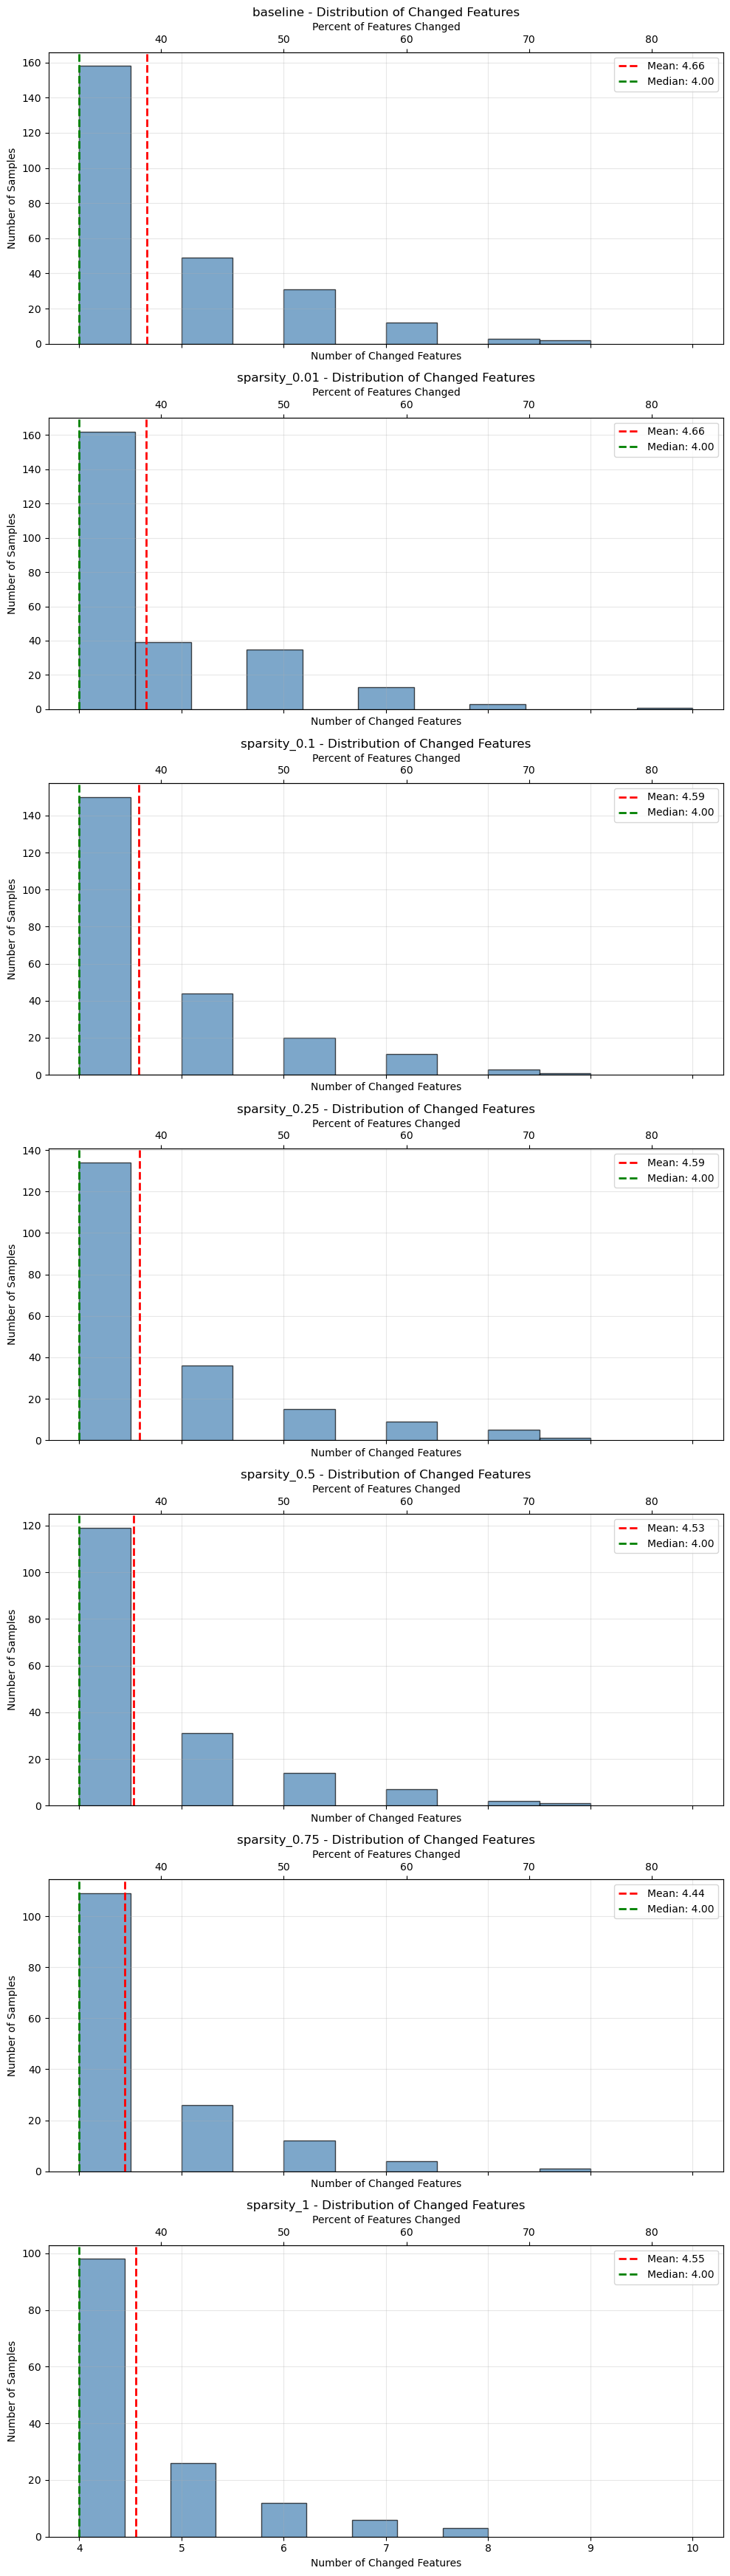

/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_86910/576650670.py:329: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_parts = plt.boxplot(data, labels=labels, patch_artist=True, showfliers=True)


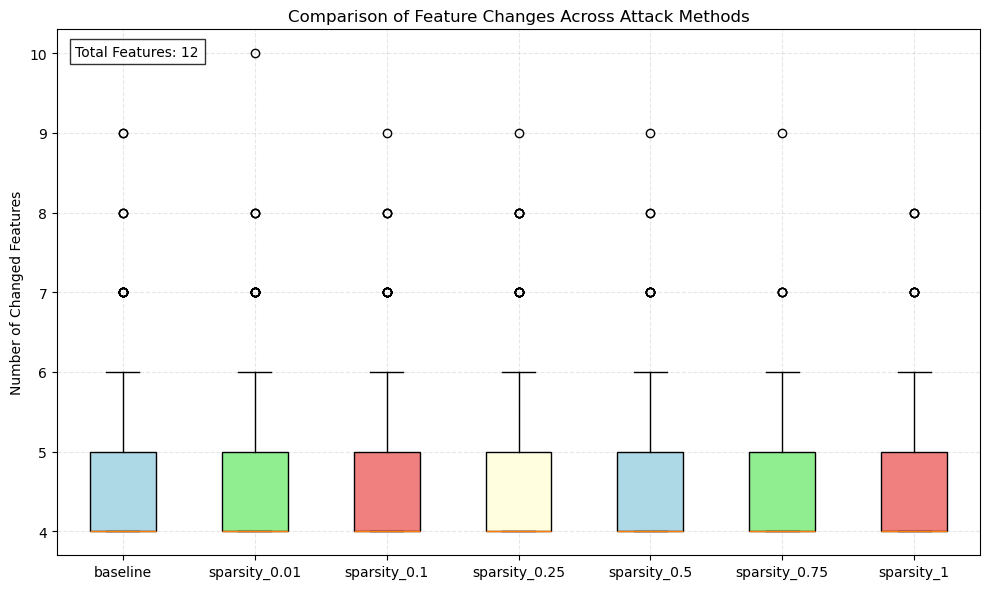

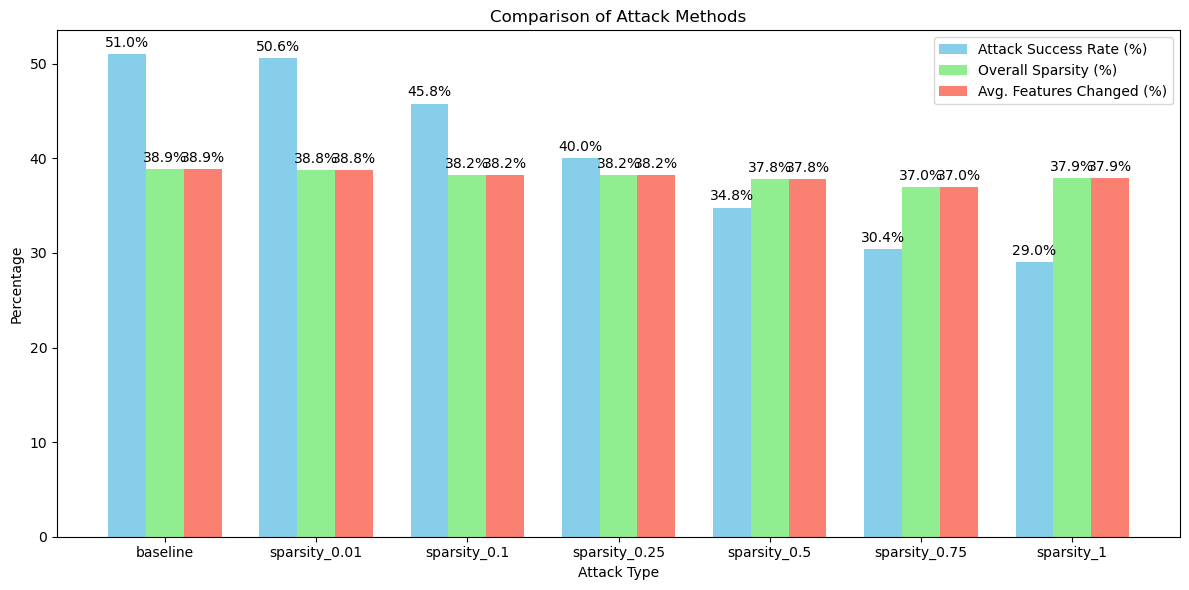

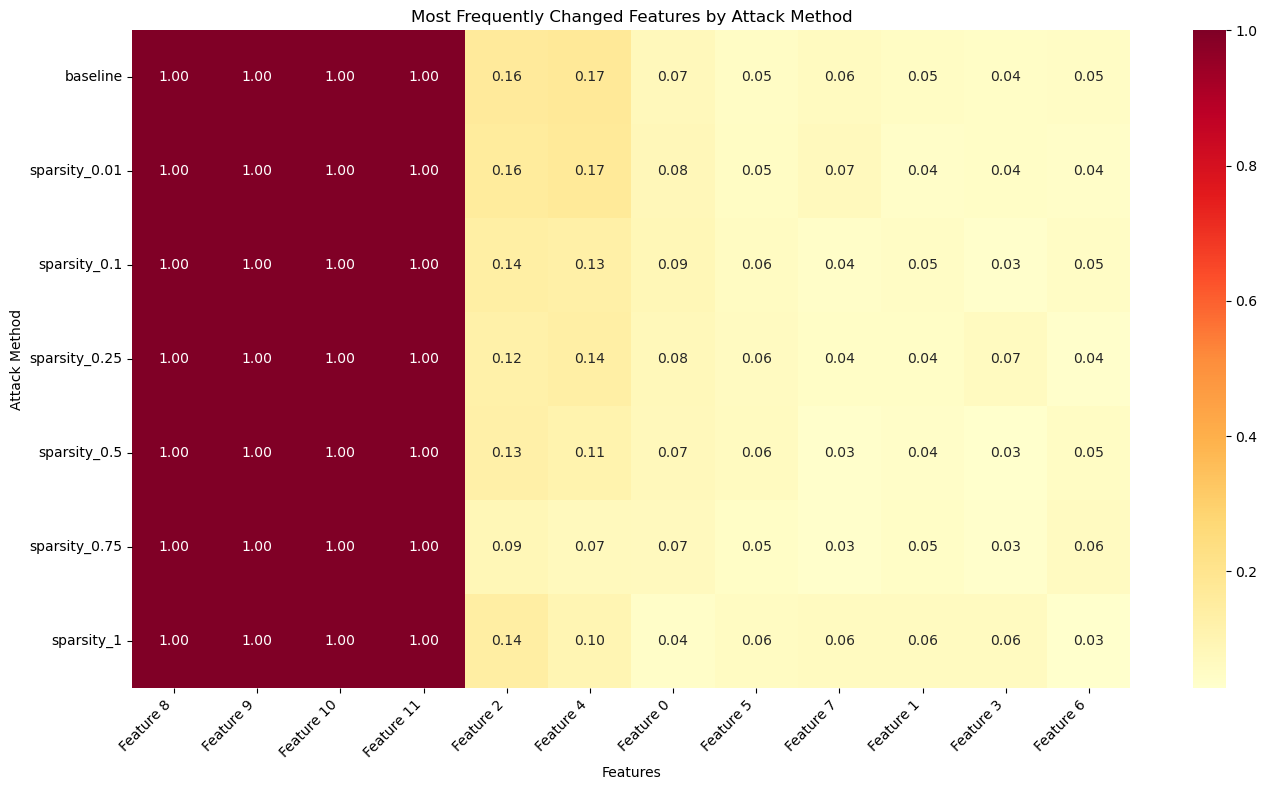

[{'attack_type': 'baseline',
  'attack_setting': 'baseline',
  'metrics': {'success_rate': np.float64(0.51),
   'overall_sparsity': np.float64(0.388562091503268),
   'avg_features_changed': np.float64(4.662745098039216),
   'median_features_changed': np.float64(4.0),
   'max_features_changed': np.int64(9),
   'min_features_changed': np.int64(4),
   'feature_counts': array([4, 4, 5, 5, 4, 4, 4, 5, 4, 8, 4, 9, 5, 5, 4, 4, 4, 5, 5, 4, 5, 4,
          5, 7, 5, 5, 7, 6, 5, 4, 5, 4, 6, 4, 4, 7, 4, 4, 5, 4, 4, 5, 5, 6,
          6, 5, 4, 4, 7, 4, 4, 5, 5, 4, 5, 4, 4, 4, 4, 6, 4, 4, 4, 4, 4, 5,
          4, 4, 4, 6, 4, 4, 5, 4, 5, 4, 5, 6, 4, 5, 8, 5, 6, 4, 5, 4, 4, 4,
          4, 4, 4, 7, 4, 4, 4, 4, 4, 6, 4, 6, 4, 4, 5, 4, 4, 5, 7, 4, 4, 6,
          6, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 5, 4, 4, 4, 5, 5, 4, 4,
          4, 6, 5, 4, 4, 5, 4, 5, 4, 6, 4, 5, 4, 5, 6, 6, 4, 4, 4, 4, 4, 4,
          6, 4, 5, 4, 4, 5, 4, 4, 7, 4, 4, 5, 6, 6, 4, 5, 4, 4, 4, 5, 5, 7,
          4, 4, 4, 5, 4, 4

In [5]:
# Define dataset and model
dataset = "adult"
# "adult", "phishing_url", "pendigit"
model = "MLP"

# Define attack configurations
baseline_config = {
    'attack_type': 'baseline',
    'attack_setting': 'baseline',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0
    }
}

sparsity_config_001 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_0.01',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 0.01
    }
}

sparsity_config_01 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_0.1',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 0.1
    }
}

sparsity_config_025 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_0.25',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 0.25
    }
}

sparsity_config_05 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_0.5',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 0.5
    }
}

sparsity_config_075 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_0.75',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 0.75
    }
}

sparsity_config_1 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_1',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 1
    }
}
sparsity_config_2 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_2',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 2
    }
}

sparsity_config_5 = {
    'attack_type': 'sparsity_l1',
    'attack_setting': 'sparsity_5',
    'params': {
        'sample_num': 500,
        '_lambda': 1,
        'lr': 0.1,
        'max_iter': 300,
        'optimizer': 'adam',
        'kappa': 0.0,
        'lambda_sparsity': 5
    }
}


# Define all attack configurations
attack_configs = [
    baseline_config,
    sparsity_config_001,
    sparsity_config_01,
    sparsity_config_025,
    sparsity_config_05,
    sparsity_config_075,
    sparsity_config_1,
    # sparsity_config_125,
    # sparsity_config_2,
    # sparsity_config_5
]

compare_attack_sparsity(dataset, model, 
                        attack_configs,
                        threshold=1e-5)


In [15]:
import torch

class DummyClass:
    def __init__(self, gamma):
        self._gamma = gamma

    def _compute_sparsity_loss(self, original_instance, adv_example):
        # Calculate absolute differences
        diff = torch.abs(original_instance - adv_example)

        # Count elements exceeding threshold (thresholded L0 norm)
        sparsity_loss = torch.sum(diff > self._gamma).float()

        return sparsity_loss

# Example Usage
original_instance = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
adv_example = torch.tensor([1.0, 2.1, 2.9, 4.5, 4.8])

dummy = DummyClass(gamma=1e-6)  # Set threshold gamma to 0.2
sparsity_loss = dummy._compute_sparsity_loss(original_instance, adv_example)

print("Sparsity Loss:", sparsity_loss.item())


Sparsity Loss: 4.0
